# 05 - Bivariate Analysis

## Dataset: Telco Customer Churn

Bivariate Analysis is used to study the relationship between two variables.

In this notebook, we will analyze:

- Numerical vs Numerical
- Numerical vs Categorical
- Categorical vs Categorical

Techniques used:

- Scatter Plot
- Box Plot
- Violin Plot
- Grouped Bar Chart
- Cross Tabulation

The objective is to identify relationships and patterns between variables.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Numerical vs Numerical

Numerical vs Numerical analysis is used to understand the relationship between two numerical variables.

Example:

- Tenure vs MonthlyCharges
- Tenure vs TotalCharges
- MonthlyCharges vs TotalCharges

A scatter plot is useful for visualizing these relationships.

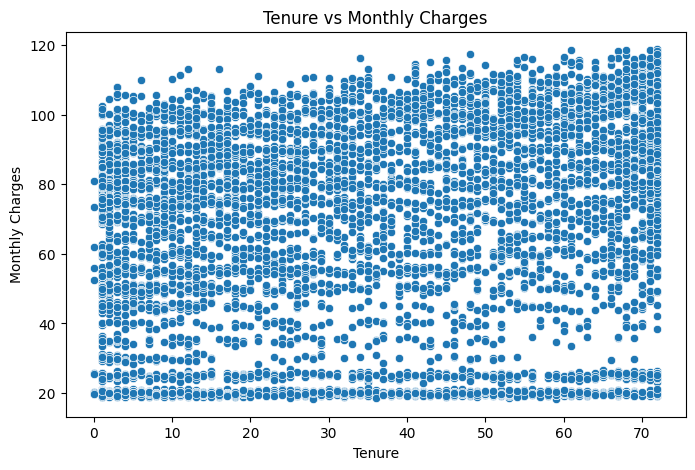

In [6]:
# Scatter Plot: Tenure vs MonthlyCharges

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges"
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

The scatter plot helps us observe whether MonthlyCharges changes with customer tenure.

The strength and direction of the relationship should be interpreted from the pattern of points.

In [7]:
# Correlation between Tenure and MonthlyCharges

df["tenure"].corr(df["MonthlyCharges"])

np.float64(0.24789985628614988)

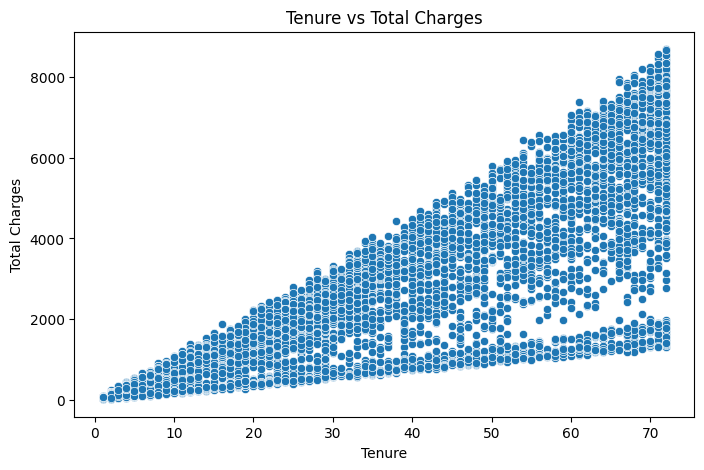

In [8]:
# Scatter Plot: Tenure vs TotalCharges

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges"
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

## 2. Numerical vs Categorical

Numerical vs Categorical analysis studies how a numerical variable differs across categories.

Examples:

- MonthlyCharges vs Contract
- TotalCharges vs Contract
- Tenure vs Churn

Box plots and violin plots are useful for this type of analysis.

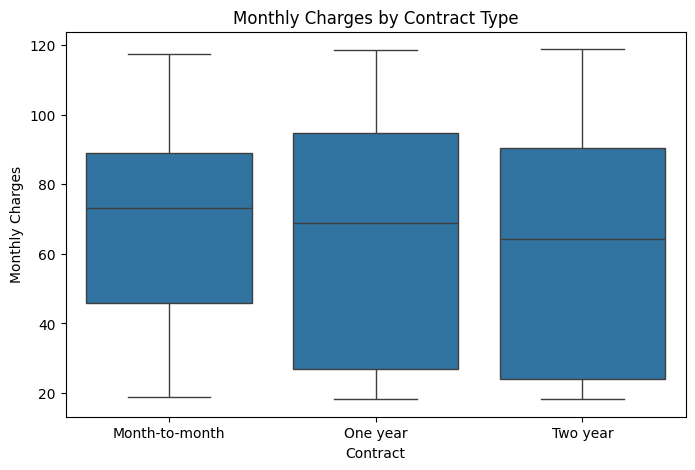

In [9]:
# Box Plot: MonthlyCharges vs Contract

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

The box plot allows us to compare the distribution of MonthlyCharges across different contract types.

We can compare the median, spread, and potential outliers for each category.

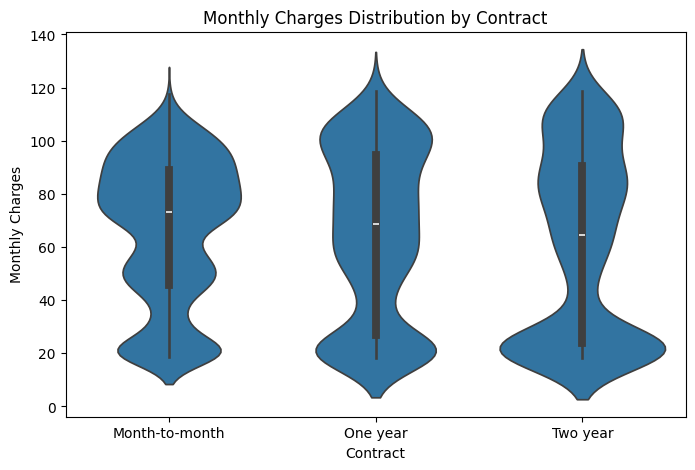

In [10]:
# Violin Plot: MonthlyCharges vs Contract

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Contract",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Contract")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")

plt.show()

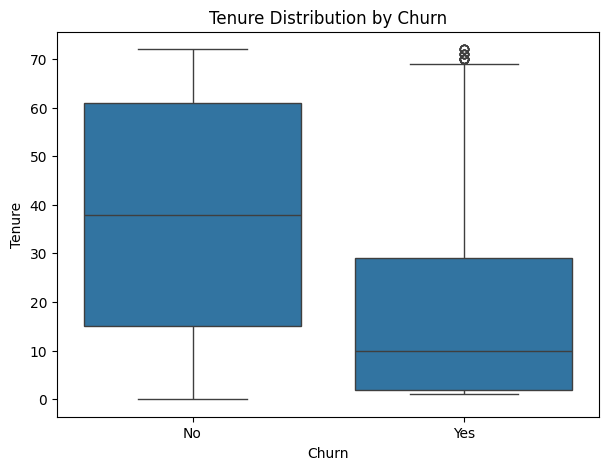

In [11]:
# Box Plot: Tenure vs Churn

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

### Observation

The box plot compares customer tenure between customers who churned and customers who did not churn.

Differences in median and distribution can indicate whether tenure is associated with customer churn.

## 3. Categorical vs Categorical

Categorical vs Categorical analysis studies the relationship between two categorical variables.

Examples:

- Contract vs Churn
- InternetService vs Churn
- PaymentMethod vs Churn

Cross tabulation and grouped bar charts can be used.

In [12]:
# Cross Tabulation: Contract vs Churn

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [13]:
# Percentage Cross Tabulation

pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


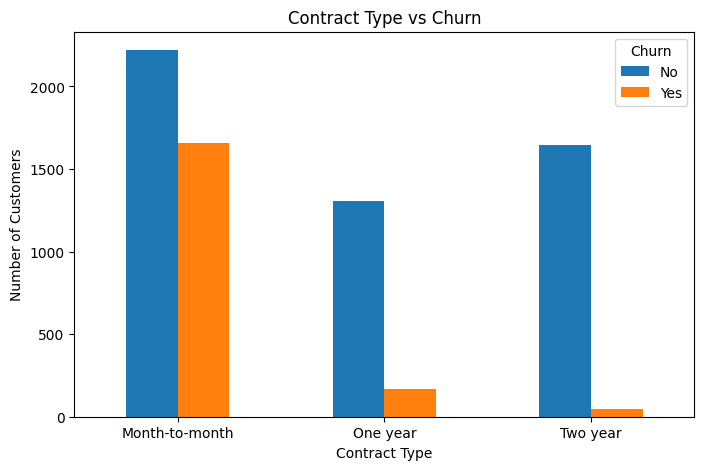

In [14]:
# Grouped Bar Chart: Contract vs Churn

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Observation

The grouped bar chart and cross-tabulation allow us to compare churn counts across different contract types.

The percentage cross-tabulation provides a better comparison of churn proportions between categories.

In [15]:
# Cross Tabulation: InternetService vs Churn

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


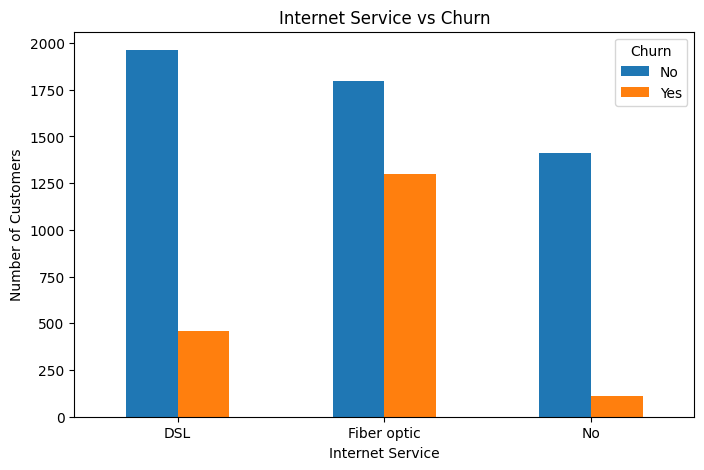

In [16]:
# Grouped Bar Chart

internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

# Bivariate Analysis Summary

### Numerical vs Numerical

Scatter plots were used to examine relationships between numerical variables such as:

- Tenure and MonthlyCharges
- Tenure and TotalCharges

### Numerical vs Categorical

Box plots and violin plots were used to compare numerical variables across categories such as:

- MonthlyCharges by Contract
- Tenure by Churn

### Categorical vs Categorical

Cross tabulation and grouped bar charts were used to study relationships such as:

- Contract and Churn
- InternetService and Churn

### Conclusion

Bivariate Analysis helps us understand how two variables are related and identify patterns that may require further investigation.